In [3]:
from roms_tools import Grid, ROMSOutput
import numpy as np
grid = Grid.from_file(
    "/home/x-uheede/S/Iceland2_MARBL_2024_60m/P_INPUT/Iceland2_grid.nc"
)

roms_output_bgc = ROMSOutput(
    grid=grid,
    path=[
        "/home/x-uheede/S/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_bgc.20240?????????.nc",
    ],
    use_dask=True,
)

roms_output_phys = ROMSOutput(
    grid=grid,
    path=[
        "/home/x-uheede/S/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_his.20240?????????.nc",
    ],
    use_dask=True,
)

var_names=['ALK','DIC']
depth_levels=np.arange(0, 40,5)



In [8]:
bgc = roms_output_bgc.regrid(depth_levels=depth_levels,var_names=var_names).load()
phys = roms_output_phys.regrid(depth_levels=depth_levels)

In [21]:
time_index = phys.indexes['time']
unique_time = ~time_index.duplicated()

phys = phys.isel(time=unique_time)
phys = phys.sortby('time')

In [14]:
time_index = bgc.indexes['time']
unique_time = ~time_index.duplicated()

bgc = bgc.isel(time=unique_time)
bgc = bgc.sortby('time')

In [20]:
salt=phys['salt'].thin({'time': 24}).load()

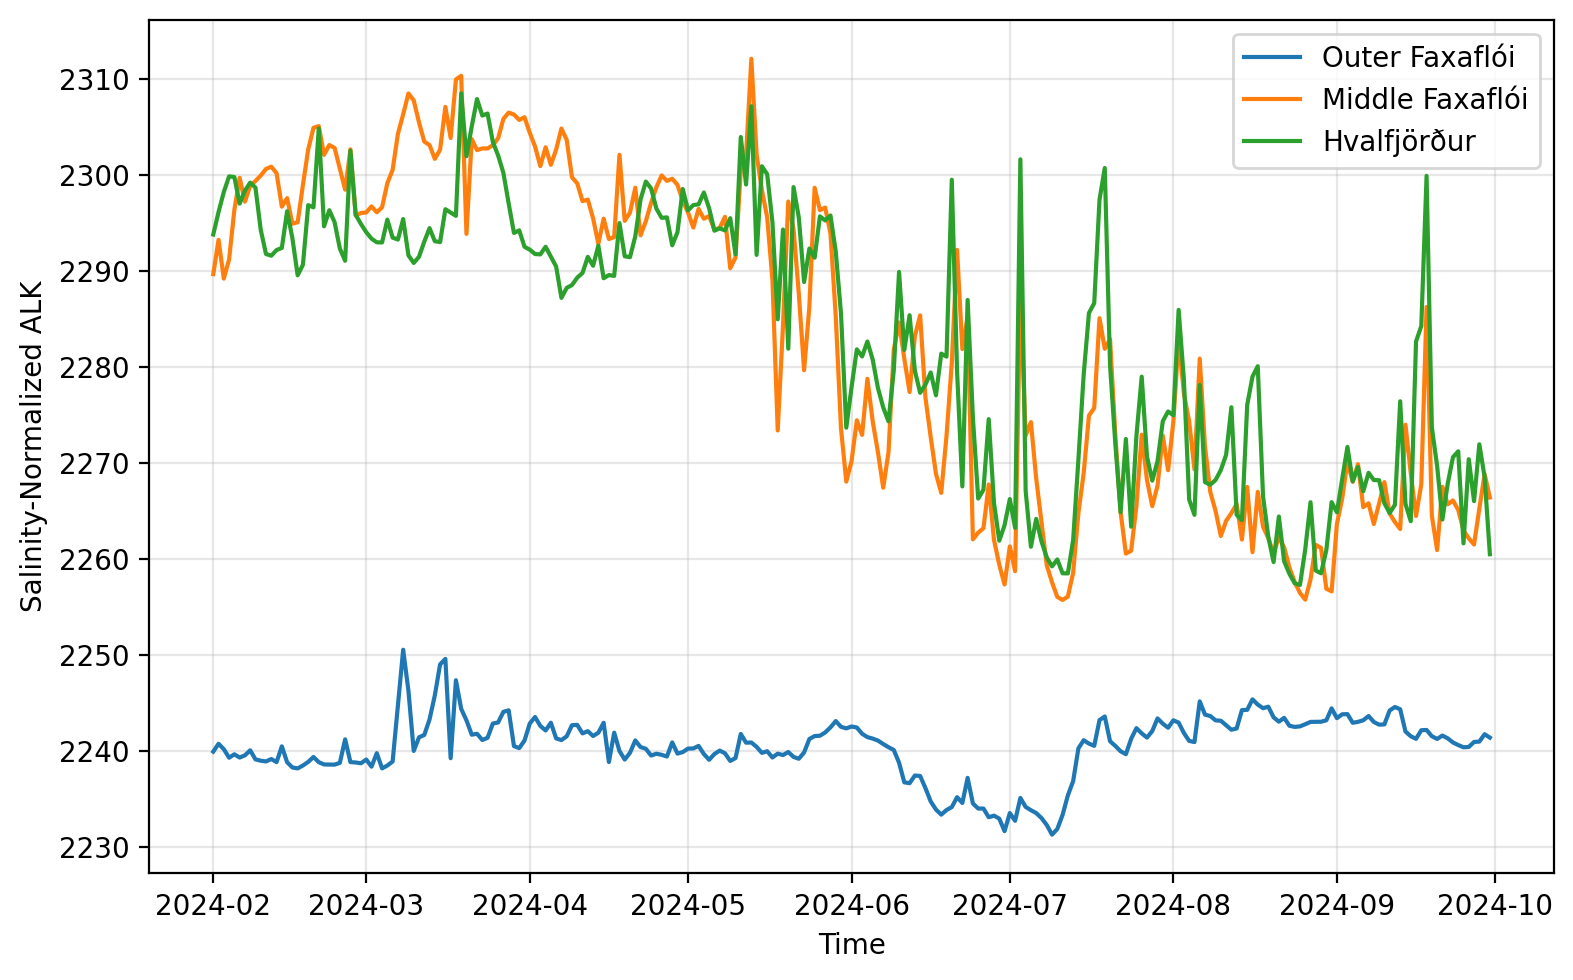

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Constants
# -----------------------
S_ref = 34
ALK0 = 250
rho = 1027

# -----------------------
# Locations (0–360 lon)
# -----------------------
locations = {
    "Outer Faxaflói":  (64.370676, 336.65133),
    "Middle Faxaflói": (64.358799, 338.230666),
    "Hvalfjörður":     (64.361560, 338.303186),
}

# -----------------------
# Surface fields
# -----------------------
alk = bgc['ALK'].sel(depth=0.0)
salt = salt.sel(depth=0.0)   # change name if needed

plt.figure(figsize=(8, 5), dpi=200)

for name, (lat, lon) in locations.items():

    alk_ts = alk.sel(lat=lat, lon=lon, method="nearest")
    salt_ts = salt.sel(lat=lat, lon=lon, method="nearest")

    # Salinity-normalized alkalinity
    nALK = (alk_ts / salt_ts) * S_ref

    # Optional: perturbation mass-normalized
    nALK_mass = (nALK - ALK0) / rho

    plt.plot(alk_ts.time, nALK, label=name)

plt.xlabel("Time")
plt.ylabel("Salinity-Normalized ALK")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

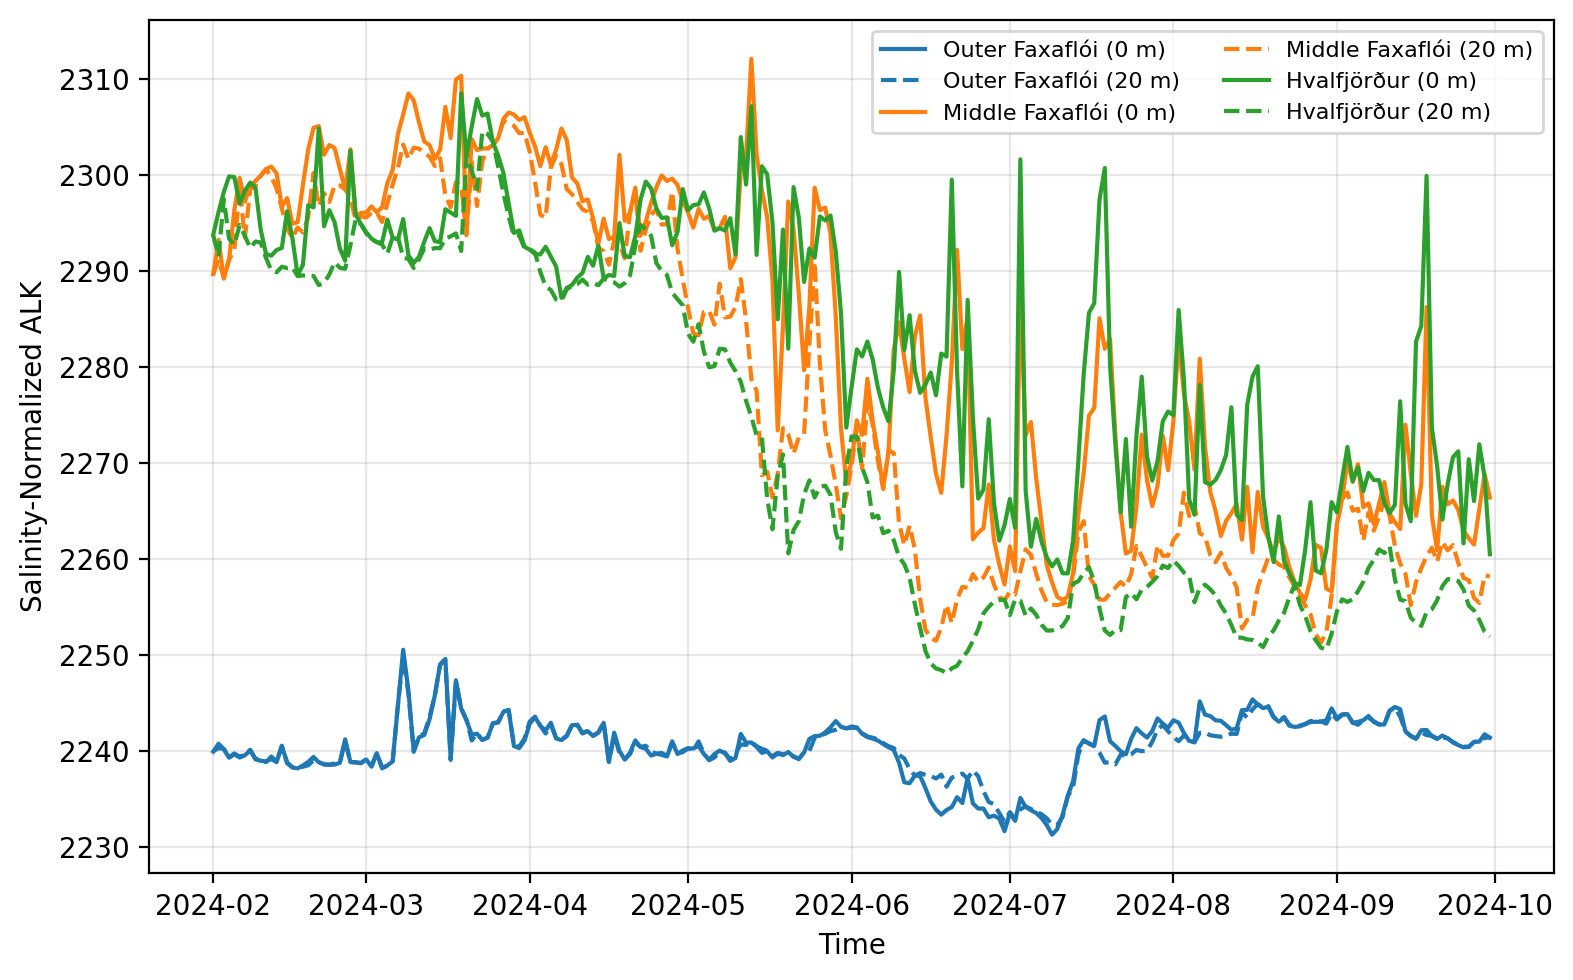

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Constants
# -----------------------
S_ref = 34
ALK0 = 250
rho = 1027

# -----------------------
# Locations (0–360 lon)
# -----------------------
locations = {
    "Outer Faxaflói":  (64.370676, 336.65133),
    "Middle Faxaflói": (64.358799, 338.230666),
    "Hvalfjörður":     (64.361560, 338.303186),
}

# -----------------------
# Select depths
# -----------------------
alk_surface = bgc['ALK'].sel(depth=0.0)
alk_20m     = bgc['ALK'].sel(depth=20, method="nearest")

salt_surface = salt.sel(depth=0.0)
salt_20m     = salt.sel(depth=20, method="nearest")

plt.figure(figsize=(8, 5), dpi=200)

for name, (lat, lon) in locations.items():

    # --- Surface ---
    alk_s = alk_surface.sel(lat=lat, lon=lon, method="nearest")
    salt_s = salt_surface.sel(lat=lat, lon=lon, method="nearest")
    nALK_s = (alk_s / salt_s) * S_ref

    # --- 20 m ---
    alk_d = alk_20m.sel(lat=lat, lon=lon, method="nearest")
    salt_d = salt_20m.sel(lat=lat, lon=lon, method="nearest")
    nALK_d = (alk_d / salt_d) * S_ref

    # Plot (same color, different linestyle)
    line, = plt.plot(alk_s.time, nALK_s, label=f"{name} (0 m)")
    plt.plot(alk_d.time, nALK_d, linestyle='--', color=line.get_color(),
             label=f"{name} (20 m)")

plt.xlabel("Time")
plt.ylabel("Salinity-Normalized ALK")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

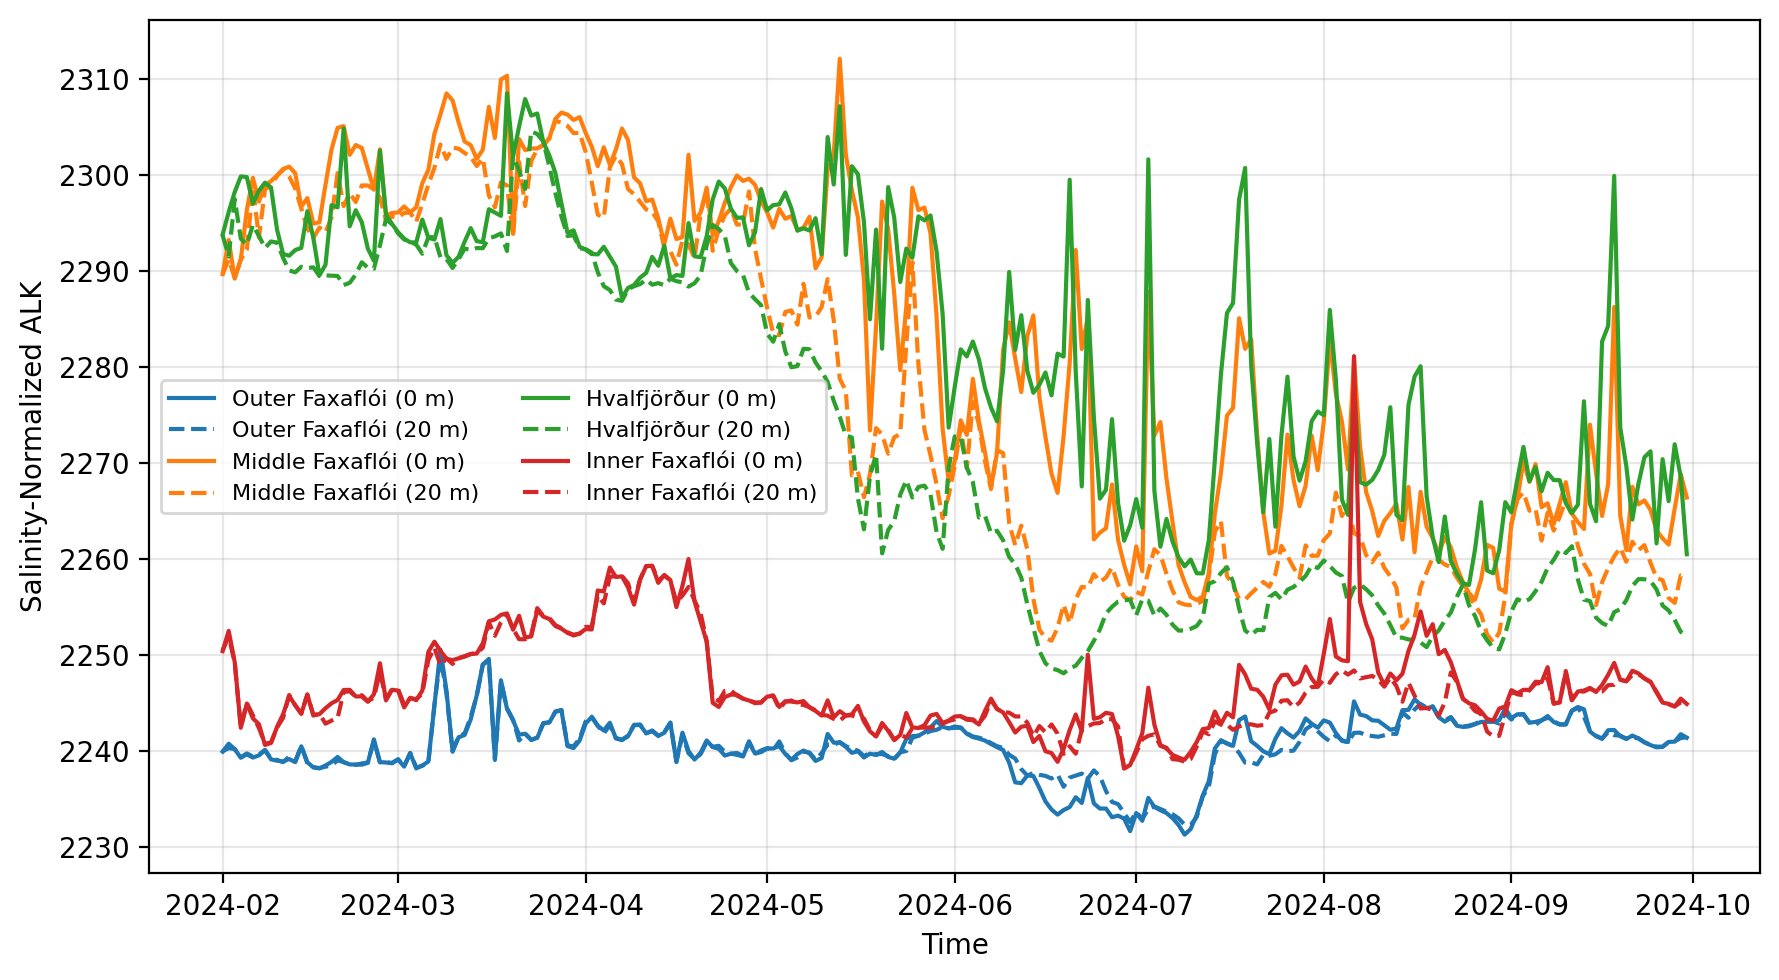

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Constants
# -----------------------
S_ref = 34
ALK0 = 250
rho = 1027

# -----------------------
# Locations (0–360 lon)
# -----------------------
locations = {
    "Outer Faxaflói":   (64.370676, 336.65133),
    "Middle Faxaflói":  (64.358799, 338.230666),
    "Hvalfjörður":      (64.361560, 338.303186),
    "Inner Faxaflói":   (64.288063, 337.456659),  # new location
}

# -----------------------
# Select depths
# -----------------------
alk_surface = bgc['ALK'].sel(depth=0.0)
alk_20m     = bgc['ALK'].sel(depth=20.0, method="nearest")

salt_surface = salt.sel(depth=0.0)
salt_20m     = salt.sel(depth=20.0, method="nearest")

plt.figure(figsize=(9, 5), dpi=200)

for name, (lat, lon) in locations.items():

    # Surface
    alk_s = alk_surface.sel(lat=lat, lon=lon, method="nearest")
    salt_s = salt_surface.sel(lat=lat, lon=lon, method="nearest")
    nALK_s = (alk_s / salt_s) * S_ref

    # 20 m
    alk_d = alk_20m.sel(lat=lat, lon=lon, method="nearest")
    salt_d = salt_20m.sel(lat=lat, lon=lon, method="nearest")
    nALK_d = (alk_d / salt_d) * S_ref

    line, = plt.plot(alk_s.time, nALK_s, label=f"{name} (0 m)")
    plt.plot(alk_d.time, nALK_d,
             linestyle='--',
             color=line.get_color(),
             label=f"{name} (20 m)")

plt.xlabel("Time")
plt.ylabel("Salinity-Normalized ALK")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

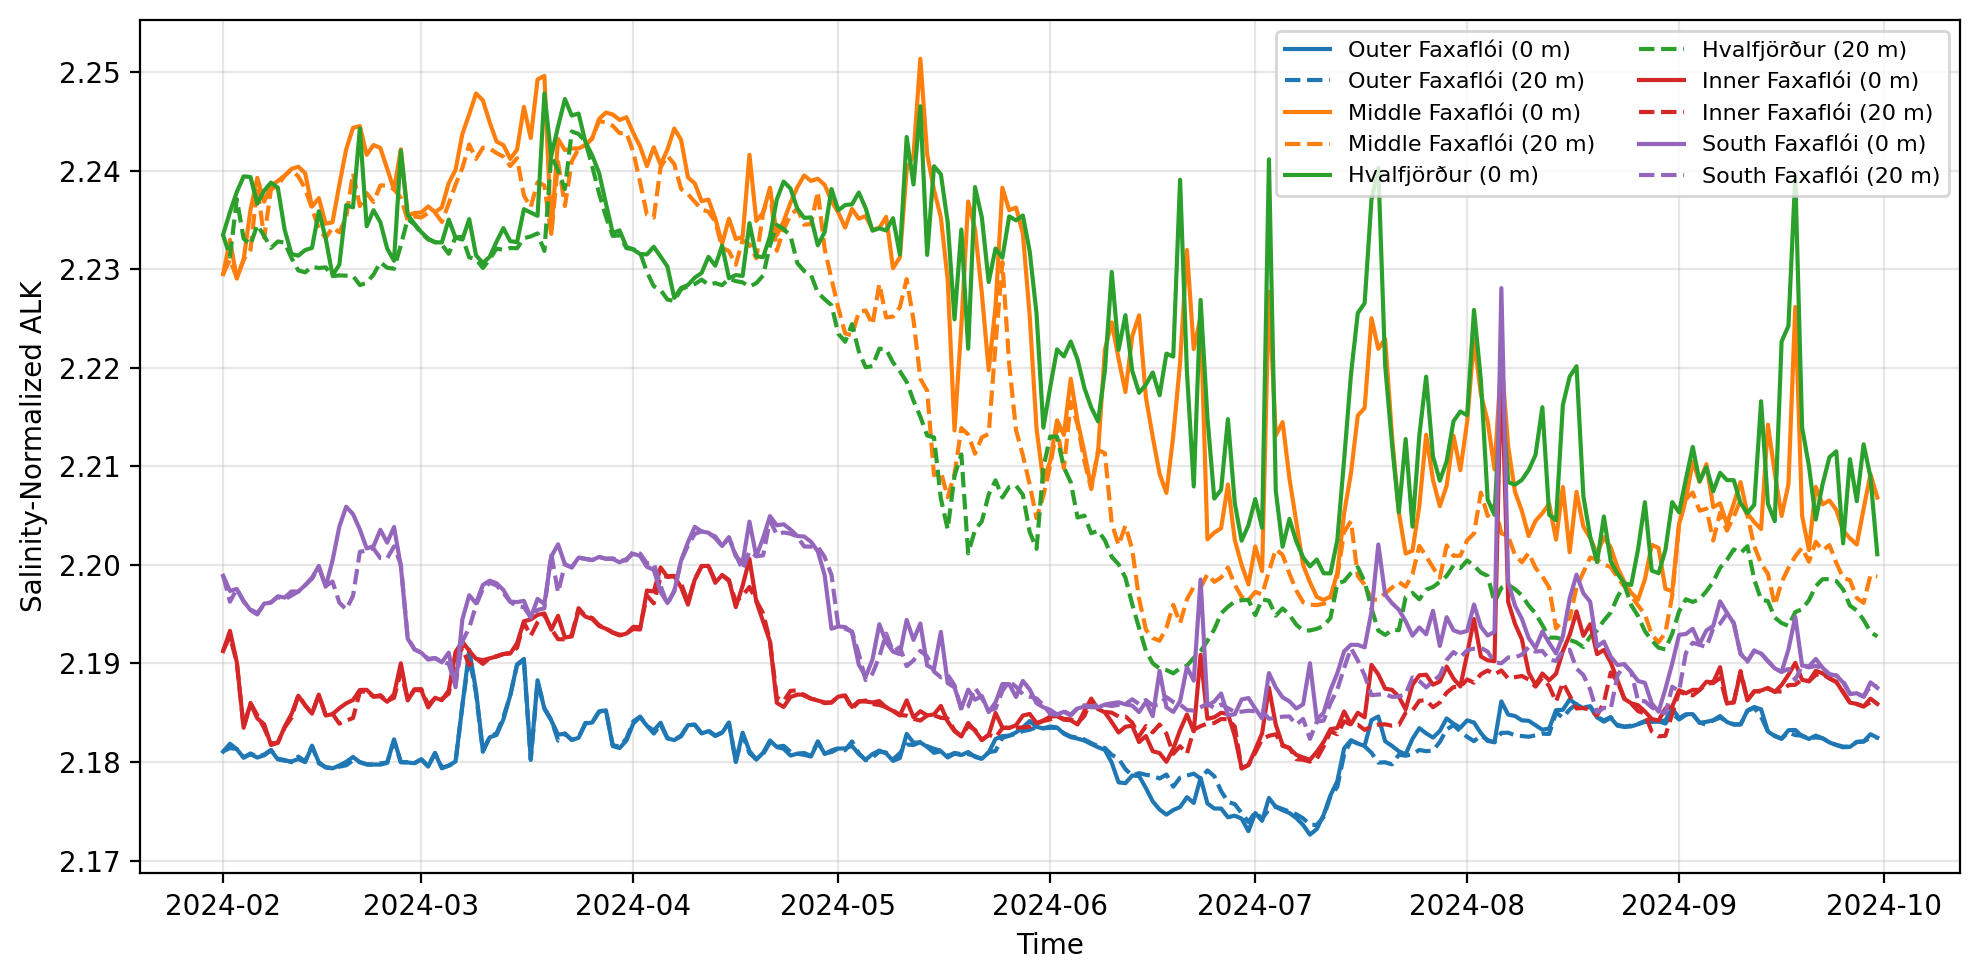

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Constants
# -----------------------
S_ref = 34
ALK0 = 250
rho = 1027

# -----------------------
# Locations (0–360 lon)
# -----------------------
locations = {
    "Outer Faxaflói":      (64.370676, 336.65133),
    "Middle Faxaflói":     (64.358799, 338.230666),
    "Hvalfjörður":         (64.361560, 338.303186),
    "Inner Faxaflói":      (64.288063, 337.456659),
    "South Faxaflói":      (64.228906, 337.707492),  # new point
}

# -----------------------
# Select depths
# -----------------------



alk_surface = bgc['ALK'].sel(depth=0.0)
alk_20m     = bgc['ALK'].sel(depth=20.0, method="nearest")

salt_surface = salt.sel(depth=0.0)
salt_20m     = salt.sel(depth=20.0, method="nearest")

plt.figure(figsize=(10, 5), dpi=200)

for name, (lat, lon) in locations.items():

    # Surface
    alk_s = alk_surface.sel(lat=lat, lon=lon, method="nearest")
    salt_s = salt_surface.sel(lat=lat, lon=lon, method="nearest")
    ALK_mass_s = alk_s / rho        # mmol kg^-1
    nALK_s = (ALK_mass_s / salt_s) * 34

    # 20 m
    alk_d = alk_20m.sel(lat=lat, lon=lon, method="nearest")
    salt_d = salt_20m.sel(lat=lat, lon=lon, method="nearest")
    ALK_mass_d = alk_d / rho        # mmol kg^-1
    nALK_d = (ALK_mass_d / salt_d) * 34
    
    line, = plt.plot(alk_s.time, nALK_s, label=f"{name} (0 m)")
    plt.plot(alk_d.time, nALK_d,
             linestyle='--',
             color=line.get_color(),
             label=f"{name} (20 m)")

plt.xlabel("Time")
plt.ylabel("Salinity-Normalized ALK")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

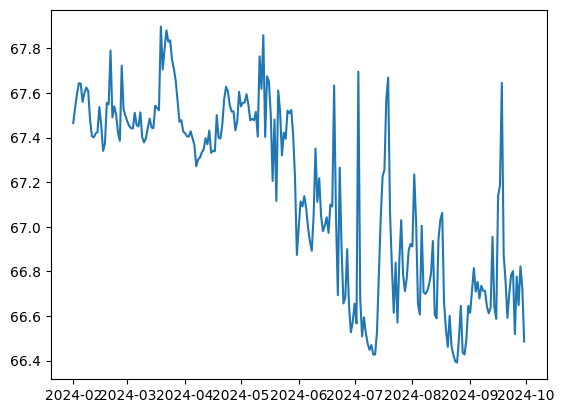

In [25]:
ratio = alk_ts / salt_ts
plt.plot(ratio.time, ratio)